In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [2]:
# load the dataset
path_to_datasets = Path().cwd().parent / "dataset"
train_df = pd.read_csv(path_to_datasets / "train.csv")
test_df = pd.read_csv(path_to_datasets / "test.csv")

In [3]:
# lets start by dropping the required columns
train_df.drop(columns=['id','recorded_by','num_private', 'scheme_name','wpt_name', 'subvillage',
               'ward', 'region_code', 'district_code', 'quantity_group',
               'payment_type', 'quality_group', 'source_type', 'waterpoint_type_group',
               'extraction_type_group', 'management_group', 'public_meeting', 'scheme_management', 'funder', 'installer'], 
               inplace=True)

# do the same for test set
test_df.drop(columns=['id','recorded_by','num_private', 'scheme_name','wpt_name', 'subvillage',
               'ward', 'region_code', 'district_code', 'quantity_group',
               'payment_type', 'quality_group', 'source_type', 'waterpoint_type_group',
               'extraction_type_group', 'management_group', 'public_meeting', 'scheme_management', 'funder', 'installer'], 
               inplace=True)

In [4]:
train_df.shape, test_df.shape

((59400, 21), (14850, 20))

In [5]:
print("Shape of the training dataset after dropping columns:", train_df.shape)
print("Shape of the test dataset after dropping columns:", test_df.shape)

Shape of the training dataset after dropping columns: (59400, 21)
Shape of the test dataset after dropping columns: (14850, 20)


In [6]:
print(train_df.dtypes)

amount_tsh               float64
date_recorded                str
gps_height                 int64
longitude                float64
latitude                 float64
basin                        str
region                       str
lga                          str
population                 int64
permit                    object
construction_year          int64
extraction_type              str
extraction_type_class        str
management                   str
payment                      str
water_quality                str
quantity                     str
source                       str
source_class                 str
waterpoint_type              str
status_group                 str
dtype: object


In [7]:
print(train_df.columns)

Index(['amount_tsh', 'date_recorded', 'gps_height', 'longitude', 'latitude',
       'basin', 'region', 'lga', 'population', 'permit', 'construction_year',
       'extraction_type', 'extraction_type_class', 'management', 'payment',
       'water_quality', 'quantity', 'source', 'source_class',
       'waterpoint_type', 'status_group'],
      dtype='str')


In [8]:
# number of categorical vs numerical features
print(f"Number of numerical features in train_df is {len(train_df.select_dtypes(include = ['number']).columns.to_list())}")
print(f"Number of categorical features in train_df is {len(train_df.select_dtypes(include = ['str', 'object']).columns.to_list())}")

# should be the same
print(f"Number of numerical features in test_df is {len(test_df.select_dtypes(include = ['number']).columns.to_list())}")
print(f"Number of categorical features in test_df is {len(test_df.select_dtypes(include = ['str', 'object']).columns.to_list())}")

Number of numerical features in train_df is 6
Number of categorical features in train_df is 15
Number of numerical features in test_df is 6
Number of categorical features in test_df is 14


### Checking missing values per feature:

In [9]:
train_df.isnull().sum()

amount_tsh                  0
date_recorded               0
gps_height                  0
longitude                   0
latitude                    0
basin                       0
region                      0
lga                         0
population                  0
permit                   3056
construction_year           0
extraction_type             0
extraction_type_class       0
management                  0
payment                     0
water_quality               0
quantity                    0
source                      0
source_class                0
waterpoint_type             0
status_group                0
dtype: int64

In [10]:
test_df.isnull().sum()

amount_tsh                 0
date_recorded              0
gps_height                 0
longitude                  0
latitude                   0
basin                      0
region                     0
lga                        0
population                 0
permit                   737
construction_year          0
extraction_type            0
extraction_type_class      0
management                 0
payment                    0
water_quality              0
quantity                   0
source                     0
source_class               0
waterpoint_type            0
dtype: int64

### Checking duplicate rows:

In [11]:
train_df.duplicated().sum()

np.int64(777)

In [12]:
# drop duplicates in train_df

# NOTE THAT WE HAVE 270 DUPLICATES IN TEST_DF WHICH MEANS THAT SINCE WE DROPPED OTHER FEATURES IN TEST
# THIS CAN ACCORDINGLY MAKE AN ERROR IN THESE 270 ROWS UNLESS THEY WERE TRULY DUPLICATE PRE-DROPPING 
train_df.drop_duplicates(inplace=True)
train_df.duplicated().sum()

np.int64(0)

### Cardinality of categorical features:

In [13]:
print(train_df.select_dtypes(include=['object', 'str']).nunique())

date_recorded            356
basin                      9
region                    21
lga                      125
permit                     2
extraction_type           18
extraction_type_class      7
management                12
payment                    7
water_quality              8
quantity                   5
source                    10
source_class               3
waterpoint_type            7
status_group               3
dtype: int64


In [14]:
# I WANT TO MAKE SURE THAT THERE ARE NO NEW WEIRD AHHH FEATURES IN THE TEST SET THAN THE ONES IN TRAINING SET
# firstly create a set out of the unique values in lga

print('diff in lga is: ',set(train_df['lga'].unique().tolist()) - set(test_df['lga'].unique().tolist()))
print('diff in region is: ',set(train_df['region'].unique().tolist()) - set(test_df['region'].unique().tolist()))

diff in lga is:  set()
diff in region is:  set()


### Statistical summary for numerical and categorical data:

In [15]:
train_df.describe(include='all')

,amount_tsh,date_recorded,gps_height,longitude,latitude,basin,region,lga,population,permit,...,extraction_type,extraction_type_class,management,payment,water_quality,quantity,source,source_class,waterpoint_type,status_group
count,58623.000000,58623,58623.000000,58623.000000,5.862300e+04,58623,58623,58623,58623.000000,55567,...,58623,58623,58623,58623,58623,58623,58623,58623,58623,58623
unique,NaN,356,NaN,NaN,NaN,9,21,125,NaN,2,...,18,7,12,7,8,5,10,3,7,3
top,NaN,2011-03-15,NaN,NaN,NaN,Lake Victoria,Iringa,Njombe,NaN,True,...,gravity,gravity,vwc,never pay,soft,enough,spring,groundwater,communal standpipe,functional
freq,NaN,572,NaN,NaN,NaN,9513,5294,2503,NaN,38525,...,26741,26741,40179,24944,50180,32748,17015,45117,28466,31818
mean,321.860581,NaN,677.154973,34.528556,-5.781631e+00,NaN,NaN,NaN,182.294543,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,3017.150144,NaN,693.382772,5.303495,2.890864e+00,NaN,NaN,NaN,474.138310,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,NaN,-90.000000,0.000000,-1.164944e+01,NaN,NaN,NaN,0.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,NaN,0.000000,33.167410,-8.579859e+00,NaN,NaN,NaN,0.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,NaN,387.000000,34.946453,-5.083189e+00,NaN,NaN,NaN,30.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,25.000000,NaN,1325.000000,37.201057,-3.344150e+00,NaN,NaN,NaN,225.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Start: Replacing 0 With NaN (Following merged_conc)

In [16]:
train_df.loc[train_df['amount_tsh'] == 0, 'amount_tsh'] = np.nan
train_df.loc[train_df['construction_year'] == 0, 'construction_year'] = np.nan
train_df.loc[train_df['population'] == 0, 'population'] = np.nan
train_df.loc[train_df['longitude'] == 0, 'longitude'] = np.nan
train_df.loc[train_df['gps_height'] <= 0, 'gps_height'] = np.nan

In [17]:
test_df.loc[test_df['amount_tsh'] == 0, 'amount_tsh'] = np.nan
test_df.loc[test_df['construction_year'] == 0, 'construction_year'] = np.nan
test_df.loc[test_df['population'] == 0, 'population'] = np.nan
test_df.loc[test_df['longitude'] == 0, 'longitude'] = np.nan
test_df.loc[test_df['gps_height'] <= 0, 'gps_height'] = np.nan

In [18]:
train_df.isnull().sum()

amount_tsh               40862
date_recorded                0
gps_height               21157
longitude                 1036
latitude                     0
basin                        0
region                       0
lga                          0
population               20604
permit                    3056
construction_year        19932
extraction_type              0
extraction_type_class        0
management                   0
payment                      0
water_quality                0
quantity                     0
source                       0
source_class                 0
waterpoint_type              0
status_group                 0
dtype: int64

In [19]:
test_df.isnull().sum()

amount_tsh               10410
date_recorded                0
gps_height                5596
longitude                  457
latitude                     0
basin                        0
region                       0
lga                          0
population                5453
permit                     737
construction_year         5260
extraction_type              0
extraction_type_class        0
management                   0
payment                      0
water_quality                0
quantity                     0
source                       0
source_class                 0
waterpoint_type              0
dtype: int64

In [20]:
# NOTICE THAT THERE ARE SOME CONSTRUCTION YEARS THAT ARE NULLS 

### Missing Values Imputation

In [21]:
# amount_tsh == amount total static head
train_df.groupby('status_group')['amount_tsh'].apply(lambda x : x.isna().mean())

status_group
functional                 0.605475
functional needs repair    0.697208
non functional             0.825816
Name: amount_tsh, dtype: float64

In [22]:
# from this we can see that amount_tsh being missing is related to the functionality of the water pump
# fa if it is non functional it is most likely for the workers to not have recorded its amount_tsh

train_df['is_tsh_missing'] = (train_df['amount_tsh'].isna()).astype(int)
train_df['is_tsh_missing']

0        0
1        1
2        0
3        1
4        1
        ..
59395    0
59396    0
59397    1
59398    1
59399    1
Name: is_tsh_missing, Length: 58623, dtype: int64

In [23]:
# we do the same for test_df too
test_df['is_tsh_missing'] = (test_df['amount_tsh'].isna()).astype(int)
test_df['is_tsh_missing']

0        1
1        1
2        1
3        1
4        0
        ..
14845    1
14846    0
14847    1
14848    1
14849    1
Name: is_tsh_missing, Length: 14850, dtype: int64

In [24]:
# lets also create these for construction, population and longitude
train_df['is_year_missing'] = train_df['construction_year'].isna().astype(int)
train_df['is_pop_missing'] = train_df['population'].isna().astype(int)
train_df['is_coord_missing'] = train_df['longitude'].isna().astype(int)

In [25]:
# same for test set
test_df['is_year_missing'] = test_df['construction_year'].isna().astype(int)
test_df['is_pop_missing'] = test_df['population'].isna().astype(int)
test_df['is_coord_missing'] = test_df['longitude'].isna().astype(int)

In [26]:
# lets look at the unique values in permit column

train_df['permit'].unique()

# probably not having permission would make the water pump more likely to be non functional
# lets look at the percentage of missing values in permit column for each status group
train_df.groupby('status_group')['permit'].apply(lambda x : x.isna().mean())

status_group
functional                 0.052580
functional needs repair    0.071582
non functional             0.047891
Name: permit, dtype: float64

In [27]:
# well there is no difference so that was not the case
# however ill not fill with mode as this is not a good idea to fill and assume that it had permission to be made
# without proper evidence
# so instead ill fill with unknown
# as much as this would increase the cardinality
# as much as it will still not be a bad idea since we will be using tree models

train_df['permit'] = train_df['permit'].fillna('Unknown')
test_df['permit'] = test_df['permit'].fillna('Unknown')

train_df['permit'] = train_df['permit'].astype(str)
test_df['permit'] = test_df['permit'].astype(str)

In [28]:
# REMEMBER TO RESEARCH MORE ABOUT THIS WHOLE CELL AND KNOW WHAT IT MEANS


cols_to_fix = ['amount_tsh', 'population', 'construction_year', 'gps_height', 'longitude']
complete_cols = train_df.columns[train_df.isnull().sum() == 0].tolist()
complete_cols = [c for c in complete_cols if c != 'status_group']


# training
for col in cols_to_fix:
    print(f"\n{col}:")
    
    for other in complete_cols:
        missing_by_group = train_df.groupby(other)[col].apply(lambda x: x.isna().mean() * 100)
        if len(missing_by_group) > 1:
            diff = missing_by_group.max() - missing_by_group.min()
            if diff > 30:
                print(f"  {other}: range = {missing_by_group.min():.1f}% - {missing_by_group.max():.1f}%")


# testing
complete_cols_test = test_df.columns[test_df.isnull().sum() == 0].tolist()
complete_cols_test = [c for c in complete_cols_test if c not in ['funder', 'installer', 'status_group']]
for col in cols_to_fix:
    print(f"\n{col}:")
    
    for other in complete_cols_test:
        missing_by_group = test_df.groupby(other)[col].apply(lambda x: x.isna().mean() * 100)
        if len(missing_by_group) > 1:
            diff = missing_by_group.max() - missing_by_group.min()
            if diff > 30:
                print(f"  {other}: range = {missing_by_group.min():.1f}% - {missing_by_group.max():.1f}%")


amount_tsh:
  date_recorded: range = 0.0% - 100.0%
  latitude: range = 0.0% - 100.0%
  basin: range = 49.0% - 95.5%
  region: range = 33.5% - 100.0%
  lga: range = 1.8% - 100.0%
  extraction_type: range = 38.0% - 100.0%
  extraction_type_class: range = 40.8% - 91.6%
  management: range = 30.3% - 94.6%
  payment: range = 15.1% - 99.8%
  water_quality: range = 68.0% - 100.0%
  source: range = 48.1% - 95.3%
  waterpoint_type: range = 60.5% - 100.0%
  is_tsh_missing: range = 0.0% - 100.0%
  is_year_missing: range = 55.1% - 98.0%
  is_pop_missing: range = 56.0% - 95.0%
  is_coord_missing: range = 69.2% - 100.0%

population:
  date_recorded: range = 0.0% - 100.0%
  latitude: range = 0.0% - 100.0%
  basin: range = 0.0% - 73.4%
  region: range = 0.0% - 100.0%
  lga: range = 0.0% - 100.0%
  extraction_type: range = 13.5% - 98.9%
  extraction_type_class: range = 14.2% - 50.8%
  management: range = 0.0% - 62.6%
  payment: range = 16.5% - 60.7%
  water_quality: range = 16.5% - 82.5%
  source: ran

In [29]:
#Now actually start replacing with the median of each group following MAR 
#except for construction_year, as per merged_conc, which would be MCAR

train_df['construction_year'] = train_df['construction_year'].fillna(1986)
test_df['construction_year'] = test_df['construction_year'].fillna(1986)


# learn statistics from training dataset to fill the missing values in both training and test datasets
# like the fit_transform from sklearn
region_amount_median = train_df.groupby('region')['amount_tsh'].median()
region_population_median = train_df.groupby('region')['population'].median()
region_height_median = train_df.groupby('region')['gps_height'].median()

extraction_longitude_median = train_df.groupby('extraction_type')['longitude'].median()

# apply to
train_df['amount_tsh'] = train_df['amount_tsh'].fillna(
    train_df['region'].map(region_amount_median)
)

train_df['population'] = train_df['population'].fillna(
    train_df['region'].map(region_population_median)
)

train_df['gps_height'] = train_df['gps_height'].fillna(
    train_df['region'].map(region_height_median)
)

train_df['longitude'] = train_df['longitude'].fillna(
    train_df['extraction_type'].map(extraction_longitude_median)
)

for col in ['amount_tsh', 'population', 'gps_height', 'longitude']:
    train_df[col] = train_df[col].fillna(train_df[col].median())


# TESTING PART
# only apply to the test
test_df['amount_tsh'] = test_df['amount_tsh'].fillna(
    test_df['region'].map(region_amount_median)
)

test_df['population'] = test_df['population'].fillna(
    test_df['region'].map(region_population_median)
)

test_df['gps_height'] = test_df['gps_height'].fillna(
    test_df['region'].map(region_height_median)
)

test_df['longitude'] = test_df['longitude'].fillna(
    test_df['extraction_type'].map(extraction_longitude_median)
)


for col in ['amount_tsh', 'population', 'gps_height', 'longitude']:
    test_df[col] = test_df[col].fillna(train_df[col].median())


In [30]:
print(train_df.isnull().sum())

amount_tsh               0
date_recorded            0
gps_height               0
longitude                0
latitude                 0
basin                    0
region                   0
lga                      0
population               0
permit                   0
construction_year        0
extraction_type          0
extraction_type_class    0
management               0
payment                  0
water_quality            0
quantity                 0
source                   0
source_class             0
waterpoint_type          0
status_group             0
is_tsh_missing           0
is_year_missing          0
is_pop_missing           0
is_coord_missing         0
dtype: int64


In [31]:
print(test_df.isnull().sum())

amount_tsh               0
date_recorded            0
gps_height               0
longitude                0
latitude                 0
basin                    0
region                   0
lga                      0
population               0
permit                   0
construction_year        0
extraction_type          0
extraction_type_class    0
management               0
payment                  0
water_quality            0
quantity                 0
source                   0
source_class             0
waterpoint_type          0
is_tsh_missing           0
is_year_missing          0
is_pop_missing           0
is_coord_missing         0
dtype: int64


In [32]:
# now for the next part which is to scale and normalize the data

# HANDLING STRING COLUMNS
# NORMALIZE VALUES
def clean_category(series):
    '''this function will take a pandas series 
    and clean the categories inside by lowercasing everything
    removing excess spaces and then titling the category aka making each first letter
    a capital letter'''

    return series.astype(str).str.strip().str.lower().str.title()

train_df['lga'] = clean_category(train_df['lga'])
test_df['lga'] = clean_category(train_df['lga'])

# next up is to reduce cardinality of the lga feature
# by taking only the top 20 categories and making the rest as "others"
lga_top = train_df['lga'].value_counts().nlargest(20).index

train_df['lga'] = train_df['lga'].apply(lambda x: x if x in lga_top else 'Other')
test_df['lga'] = test_df['lga'].apply(lambda x: x if x in lga_top else 'Other')

In [33]:
# ill frequency encode the lga feature
value_counts_lga = train_df['lga'].value_counts(normalize=True) * 100

train_df['lga_freq'] = train_df['lga'].map(value_counts_lga)
test_df['lga_freq'] = test_df['lga'].map(value_counts_lga)

In [34]:
# now lets one hot encode the rest of the features
# lets first recheck the nunique of each
train_df.select_dtypes(include = ['str', 'object']).nunique()

date_recorded            356
basin                      9
region                    21
lga                       21
permit                     3
extraction_type           18
extraction_type_class      7
management                12
payment                    7
water_quality              8
quantity                   5
source                    10
source_class               3
waterpoint_type            7
status_group               3
dtype: int64

In [35]:
train_df['amount_tsh'] = np.log1p(train_df['amount_tsh'])
test_df['amount_tsh'] = np.log1p(test_df['amount_tsh'])

train_df['population'] = np.log1p(train_df['population'])
test_df['population'] = np.log1p(test_df['population'])

# scaling in test with log1p is causing nulls

In [36]:
# NOW CAPTURE THE MONTH AND YEAR RECORDED
train_df['year_recorded'] = pd.to_datetime(train_df['date_recorded']).dt.year
train_df['month_recorded'] = pd.to_datetime(train_df['date_recorded']).dt.month


test_df['year_recorded'] = pd.to_datetime(test_df['date_recorded']).dt.year
test_df['month_recorded'] = pd.to_datetime(test_df['date_recorded']).dt.month

train_df.drop(columns = ['date_recorded'], inplace = True)
test_df.drop(columns = ['date_recorded'], inplace = True)

In [37]:
from sklearn.preprocessing import OneHotEncoder

cat_features = [value for value in train_df.select_dtypes(include = ['object', 'str']).columns if value not in ['status_group', 'source']]

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

train_df_encoded = ohe.fit_transform(train_df[cat_features]).astype(int)
test_df_encoded = ohe.transform(test_df[cat_features]).astype(int)  #type: ignore

# convert back to being a dataframe and concatenate with original df
train_df_encoded = pd.DataFrame(train_df_encoded, columns=ohe.get_feature_names_out(cat_features))
test_df_encoded = pd.DataFrame(test_df_encoded, columns=ohe.get_feature_names_out(cat_features))
train_df = pd.concat([train_df.reset_index(drop=True), train_df_encoded.reset_index(drop=True)], axis=1)
test_df = pd.concat([test_df.reset_index(drop=True), test_df_encoded.reset_index(drop=True)], axis=1)

train_df.drop(columns=cat_features, inplace=True)
test_df.drop(columns=cat_features, inplace=True)

In [38]:
train_df.shape, test_df.shape

((58623, 136), (14850, 135))

In [39]:

num_cols = ['amount_tsh', 'gps_height', 'longitude', 'latitude',  # original
            'population', 'construction_year', 'year_recorded', 'month_recorded']

print("Outlier check after scaling (IQR method):")
for col in num_cols:
    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((train_df[col] < lower) | (train_df[col] > upper)).sum()
    print(f"  {col}: {n_out} outliers ({n_out/len(train_df)*100:.1f}%)")

Outlier check after scaling (IQR method):
  amount_tsh: 109 outliers (0.2%)
  gps_height: 1281 outliers (2.2%)
  longitude: 0 outliers (0.0%)
  latitude: 0 outliers (0.0%)
  population: 7308 outliers (12.5%)
  construction_year: 0 outliers (0.0%)
  year_recorded: 31 outliers (0.1%)
  month_recorded: 0 outliers (0.0%)


In [40]:
# TASK 4:

# after handling the data
# check the correlation between the features and the target variable
# look at their variance too and try to only without dropping anything
# check if there are any features that have low variance which can indicate
# that they are not useful for the model and can be dropped

In [41]:
# firstly lets look if i can make a categorical feature out of latitude and longtitude
# by creating a feature named "cluster" using KMeans clustering
# this can help in capturing spatial patterns in the data that may be relevant for predicting the target variable
# and it can also help in reducing the dimensionality of the data by grouping similar locations together

# i need to check if they can be separated into clusters by firstly plotting their scatter plots together

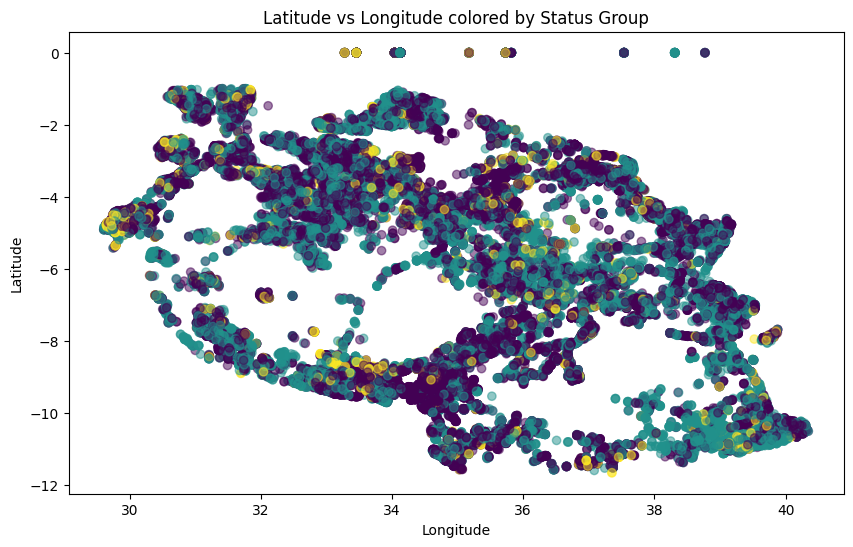

In [42]:
plt.figure(figsize=(10, 6))

plt.scatter(train_df['longitude'], train_df['latitude'], alpha=0.5,
            c = train_df['status_group'].map({'functional': 0, 'non functional': 1, 'functional needs repair': 2}),
            cmap='viridis')

plt.title('Latitude vs Longitude colored by Status Group')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()


# NOTE THAT PURPLE == FUNCTIONAL
# CYAN == NON FUNCTIONAL
# YELLOW == FUNCTIONAL NEEDS REPAIR

In [43]:
# # Using KMEANS TO CREATE CLUSTERS
# from sklearn.cluster import KMeans

# # lets create 10 clusters as a starting point 
# kmeans = KMeans(n_clusters=10, random_state=42)
# train_df['geo_cluster'] = kmeans.fit_predict(train_df[['longitude', 'latitude']])

# train_df['geo_cluster']

In [44]:
# lets check if it is of any importance by looking at the distribution of the target variable across the clusters

# print("\nDistribution of status_group across geo_clusters:")
# plt.figure(figsize=(12, 6))
# sns.countplot(data=train_df, x='geo_cluster', hue='status_group')
# plt.title('Distribution of Status Group across Geo Clusters')
# plt.xlabel('Geo Cluster')
# plt.ylabel('Count')
# plt.show()

# as we can see
# cluster 8 has a very high proportion of being non functional compared to other clusters
# remember to adjust the number of clusters and find the best number of clusters using silhouette score

In [45]:
# # lets do that now
# from sklearn.metrics import silhouette_score
# silhouette_scores = []
# for n in range(2, 15):
#     kmeans = KMeans(n_clusters=n, random_state=42)
#     labels = kmeans.fit_predict(preprocessed_df[['longitude', 'latitude']])
#     score = silhouette_score(preprocessed_df[['longitude', 'latitude']], labels)
#     silhouette_scores.append(score)


# silhouette_scores

In [46]:
# okay so at the end we can use the 12 cluster instead
# lets create 12 clusters
# kmeans = KMeans(n_clusters=12, random_state=42)
# train_df['geo_cluster'] = kmeans.fit_predict(train_df[['longitude', 'latitude']])
# test_df['geo_cluster'] = kmeans.predict(test_df[['longitude', 'latitude']])

# train_df['geo_cluster']

In [47]:
# as to whether we will use this feature or not will depend on the model
# we will try to train without it and calculate cross validation score once
# and then try again with it and see if it improves the score or not

In [48]:
# secondly we want to make a installer * lga feature
# this is because lga determines the location of the pump and which government is responsible for it
# while installer determines who and how was the pump installed and thus is more in-detailed info about the pump
# making a feature that combines both can firstly reduce the dimensionality
# secondly be more deterministic as it combines which country and which installer together
# to do so though we need to encode them using target encoding instead of frequency encoding
# as the advantage in target encoding here is that it can capture the relation between the category itself in each feature
# and the target variable and replace the feature with the probability mean of each category
# using frequency encoding is better when u want to see the population of a category
# but target encoding is better when u want to capture the relation between the category and the target variable

# NOTE: REVERT THE FREQUENCY ENCODING OF INSTALLER AND LGA TO DO TARGET ENCODING IN THE COMBINED FEATURE

In [49]:
# lets create a pump_age feature by subtracting the construction_year from the year_recorded
# we need to use the original year_recorded before scaling for this calculation
# we need to revert the robust scaling for year_recorded and construction_year to do this calculation correctly
# to do so 
# the robust scaling = (x - median) / IQR
# so to revert it we do: x = (scaled_x * IQR) + median
# however we dont have the iqr nor the mean from the original feature so ill just comment the part above for now

train_df['pump_age'] = train_df['year_recorded'] - train_df['construction_year']
test_df['pump_age'] = test_df['year_recorded'] - test_df['construction_year']

train_df['pump_age']

0        12.0
1         3.0
2         4.0
3        27.0
4        25.0
         ... 
58618    14.0
58619    15.0
58620    25.0
58621    25.0
58622     9.0
Name: pump_age, Length: 58623, dtype: float64

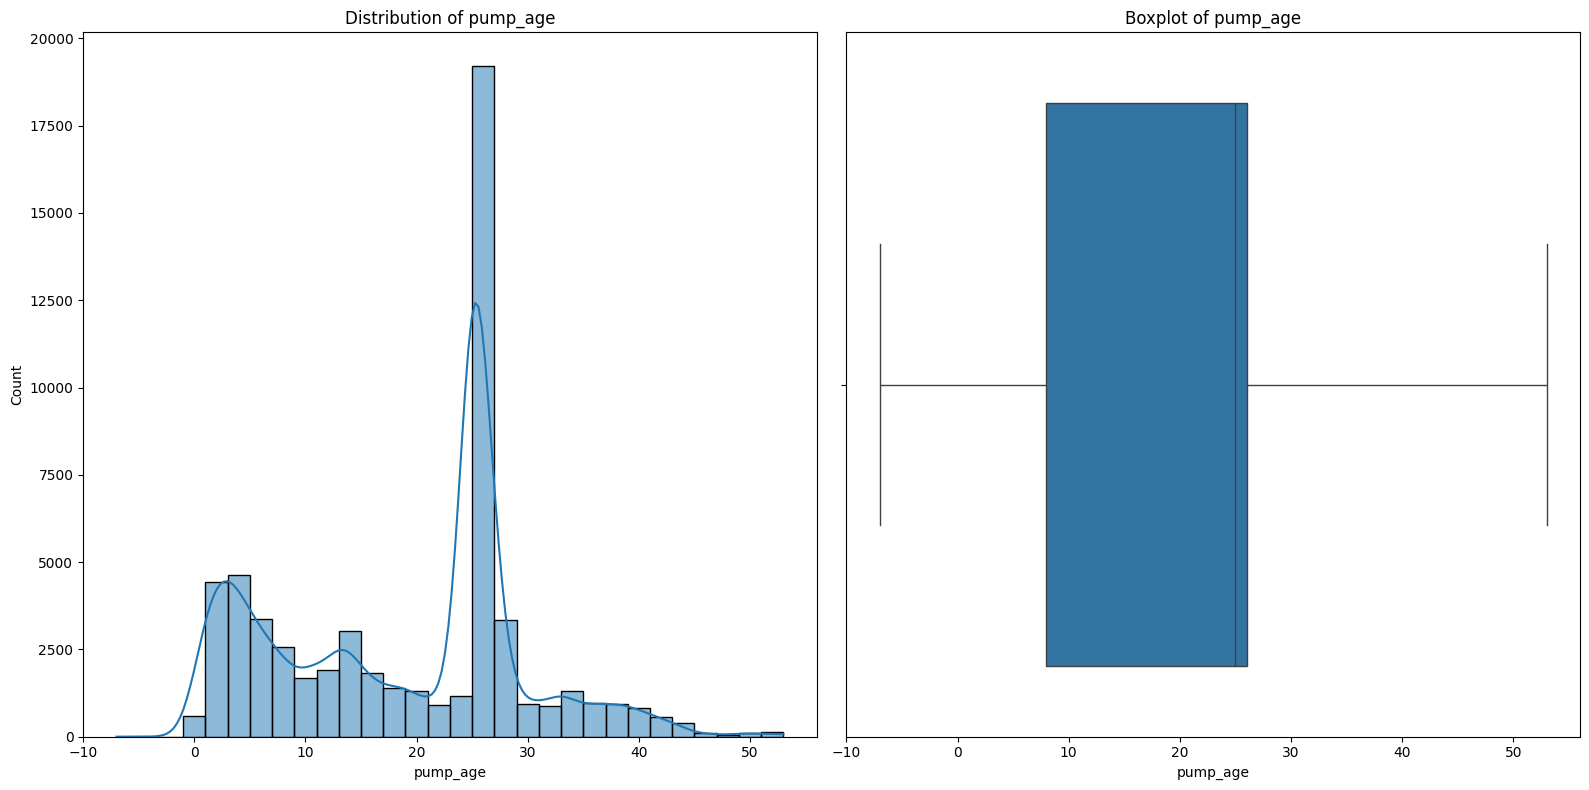

In [50]:
# let me look at its distribution real quick
plt.figure(figsize=(16, 8))

# plot its distribution first
plt.subplot(1, 2, 1)
sns.histplot(train_df['pump_age'], bins=30, kde=True)    #type: ignore
plt.title('Distribution of pump_age')

plt.subplot(1, 2, 2)
sns.boxplot(x=train_df['pump_age'])    #type: ignore
plt.title('Boxplot of pump_age')

plt.tight_layout()
plt.show()

In [51]:
train_df['pump_age'].skew()

np.float64(-0.028941508949002097)

In [52]:
train_df['pump_age'].kurtosis()

np.float64(-0.8068382491281638)

In [53]:
# as we can see this is a really strong feature as its skewness, kurtosis 
# AND IS ABUNDANT IN OUTLIERS WHICH AS A BASELINE IS A REALLY GOOD SIGNAL FOR THE FEATURES

In [54]:
# i want to look at smth now
# i want to look at each month with each installer category to see if there is a pattern between the month of installation and the installer and how it affects the target variable
# to do so i will create a new feature that combines the installer and the month of installation and then look at the distribution of the target variable across this new feature
# train_df['installer_month'] = train_df['installer_frequency'].astype(str) + '_' + train_df['month_recorded'].astype(str)

# train_df[['installer_month', 'status_group']].value_counts(normalize=True)

In [55]:
# well i dont see a clear pattern here so we will just drop it
# preprocessed_df = train_df.drop(columns=['installer_month'])

In [56]:
# let me look at the geo_cluster * source feature to see if there is a pattern

# we need to unlock the setting to show all the rows in the crosstab output
# pd.set_option('display.max_rows', None)

# pd.crosstab(
#     [train_df['geo_cluster'], train_df['source']],
#     train_df['status_group'],
#     normalize='index'
# )

In [57]:
# as we can see the dam cateogory for example is acting differently in each cluster individually 
# for example dam in cluster 1 means that it is 100% non functional
# while being dam but in cluster 0 or 11 means that is more likely to be functional
# being in cluster 10 as dam means that again it is most likely to be non functional

# which summarizes that we can see a pattern in the geo_cluster * source feature
# so we can use it

In [58]:
# train_df['geo_cluster_source'] = train_df['geo_cluster'].astype(str) + '_' + train_df['source'].astype(str)
# test_df['geo_cluster_source'] = test_df['geo_cluster'].astype(str) + '_' + test_df['source'].astype(str)

In [59]:
# train_df['geo_cluster_source'].value_counts(normalize=True)

In [60]:
train_df.drop(columns = ['source'], inplace = True)
test_df.drop(columns = ['source'], inplace = True)

In [61]:
# train_df['geo_cluster_source'].nunique()

In [62]:
from sklearn.model_selection import StratifiedKFold

def target_encode_oof(train, test, col, target, n_splits=5, alpha=10):

    global_mean = target.mean()

    oof = np.zeros(len(train))
    test_pred = np.zeros(len(test))

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    for train_idx, val_idx in skf.split(train, target):

        X_tr, X_val = train.iloc[train_idx], train.iloc[val_idx]
        y_tr = target.iloc[train_idx]

        stats = X_tr.groupby(col)[target.name].agg(['mean', 'count'])

        # smoothing
        smooth = (stats['mean'] * stats['count'] + global_mean * alpha) / (stats['count'] + alpha)

        oof[val_idx] = X_val[col].map(smooth).fillna(global_mean)
        test_pred += test[col].map(smooth).fillna(global_mean) / n_splits

    return oof, test_pred

In [63]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
train_df['status_group_encoded'] = le.fit_transform(train_df['status_group'])   #type: ignore

In [64]:
# train_df['geo_source_te'], test_df['geo_source_te'] = target_encode_oof(
#     train_df,
#     test_df,
#     col='geo_cluster_source',
#     target=train_df['status_group_encoded']
# )

In [65]:
# train_df['geo_source_te']

In [66]:
# test_df['geo_source_te']

In [67]:
# # create frequency encoded feature too
# geo_source_freq = train_df['geo_cluster_source'].value_counts(normalize=True) * 100
# train_df['geo_source_freq'] = train_df['geo_cluster_source'].map(geo_source_freq)
# test_df['geo_source_freq'] = test_df['geo_cluster_source'].map(geo_source_freq)

In [68]:
# drop the geo_cluster_source feature as we have encoded it now
# train_df.drop(columns = ['geo_cluster_source'], inplace = True)
# test_df.drop(columns = ['geo_cluster_source'], inplace = True)
train_df.drop(columns = ['status_group_encoded'], inplace = True)

In [69]:
train_df.head()

,amount_tsh,gps_height,longitude,latitude,population,construction_year,status_group,is_tsh_missing,is_year_missing,is_pop_missing,...,source_class_surface,source_class_unknown,waterpoint_type_cattle trough,waterpoint_type_communal standpipe,waterpoint_type_communal standpipe multiple,waterpoint_type_dam,waterpoint_type_hand pump,waterpoint_type_improved spring,waterpoint_type_other,pump_age
0,8.699681,1390.0,34.938093,-9.856322,4.700480,1999.0,functional,0,0,0,...,0,0,0,1,0,0,0,0,0,12.0
1,4.615121,1399.0,34.698766,-2.147466,5.638355,2010.0,functional,1,0,0,...,1,0,0,1,0,0,0,0,0,3.0
2,3.258097,686.0,37.460664,-3.821329,5.525453,2009.0,functional,0,0,0,...,1,0,0,0,1,0,0,0,0,4.0
3,3.931826,263.0,38.486161,-11.155298,4.077537,1986.0,non functional,1,0,0,...,0,0,0,0,1,0,0,0,0,27.0
4,5.525453,1189.0,31.130847,-1.825359,5.303305,1986.0,functional,1,1,1,...,1,0,0,1,0,0,0,0,0,25.0


In [70]:
test_df.head()

,amount_tsh,gps_height,longitude,latitude,population,construction_year,is_tsh_missing,is_year_missing,is_pop_missing,is_coord_missing,...,source_class_surface,source_class_unknown,waterpoint_type_cattle trough,waterpoint_type_communal standpipe,waterpoint_type_communal standpipe multiple,waterpoint_type_dam,waterpoint_type_hand pump,waterpoint_type_improved spring,waterpoint_type_other,pump_age
0,3.931826,1996.0,35.290799,-4.059696,5.774552,2012.0,1,0,0,0,...,1,0,0,0,0,0,0,0,1,1.0
1,3.044522,1569.0,36.656709,-3.309214,5.707110,2000.0,1,0,0,0,...,0,0,0,1,0,0,0,0,0,13.0
2,3.931826,1567.0,34.767863,-5.004344,6.216606,2010.0,1,0,0,0,...,1,0,0,0,0,0,0,0,1,3.0
3,3.931826,267.0,38.058046,-9.418672,5.525453,1987.0,1,0,0,0,...,0,0,0,0,0,0,0,0,1,26.0
4,6.216606,1260.0,35.006123,-10.950412,4.110874,2000.0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,13.0


In [71]:
test_df.isnull().sum()

amount_tsh                         0
gps_height                         0
longitude                          0
latitude                           0
population                         0
                                  ..
waterpoint_type_dam                0
waterpoint_type_hand pump          0
waterpoint_type_improved spring    0
waterpoint_type_other              0
pump_age                           0
Length: 135, dtype: int64

In [72]:
# save the preprocessed datasets
train_df.to_csv(path_to_datasets / "train_clean.csv", index=False)
test_df.to_csv(path_to_datasets / "test_clean.csv", index=False)